# **Finding Missing Values**


Data wrangling is the process of cleaning, transforming, and organizing data to make it suitable for analysis. Finding and handling missing values is a crucial step in this process to ensure data accuracy and completeness. In this lab, you will focus exclusively on identifying and handling missing values in the dataset.


## Objectives


After completing this lab, you will be able to:


-   Identify missing values in the dataset.

- Quantify missing values for specific columns.

- Impute missing values using various strategies.


## Hands on Lab


##### Setup: Install Required Libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install numpy
!matplotlib inline

/bin/bash: line 1: matplotlib: command not found


##### Import Necessary Modules:


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

## Tasks


<h2>1. Load the Dataset</h2>
<p>
We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


The functions below will download the dataset into your browser:



In [3]:
# Define the URL of the dataset
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### 2. Explore the Dataset
##### Task 1: Display basic information and summary statistics of the dataset.


In [4]:
# Display basic information
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 56.9 MB
None


In [5]:
# Summary statistics
df.describe()

,ResponseId,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat
count,65437.000000,3.374000e+04,29658.000000,29324.000000,29393.000000,29411.000000,29450.000000,29448.00000,29456.000000,29456.000000,29450.000000,29445.000000,2.343500e+04,29126.000000
mean,32719.000000,2.963841e+145,11.466957,18.581094,7.522140,10.060857,24.343232,22.96522,20.278165,16.169432,10.955713,9.953948,8.615529e+04,6.935041
std,18890.179119,5.444117e+147,9.168709,25.966221,18.422661,21.833836,27.089360,27.01774,26.108110,24.845032,22.906263,21.775652,1.867570e+05,2.088259
min,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000
25%,16360.000000,6.000000e+04,4.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,3.271200e+04,6.000000
50%,32719.000000,1.100000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.00000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000
75%,49078.000000,2.500000e+05,16.000000,22.000000,5.000000,10.000000,30.000000,30.00000,25.000000,20.000000,10.000000,10.000000,1.079715e+05,8.000000
max,65437.000000,1.000000e+150,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,1.625660e+07,10.000000


### 3. Finding Missing Values
##### Task 2: Identify missing values for all columns.


In [7]:
missing_values = df.isnull().sum()

# Display the first 20 columns with missing values
print(missing_values.head(20))

ResponseId               0
MainBranch               0
Age                      0
Employment               0
RemoteWork           10631
Check                    0
CodingActivities     10971
EdLevel               4653
LearnCode             4949
LearnCodeOnline      16200
TechDoc              24540
YearsCode             5568
YearsCodePro         13827
DevType               5992
OrgSize              17957
PurchaseInfluence    18031
BuyNewTool           20256
BuildvsBuy           22079
TechEndorse          21769
Country               6507
dtype: int64


In [8]:
missing_columns = missing_values[missing_values > 0]

print("Columns with missing values:")
print(missing_columns)

Columns with missing values:
RemoteWork             10631
CodingActivities       10971
EdLevel                 4653
LearnCode               4949
LearnCodeOnline        16200
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 109, dtype: int64


In [9]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
# Sort by highest percentage
print(missing_percentage.sort_values(ascending=False).head(20))

AINextMuch less integrated       98.245641
AINextLess integrated            96.401119
AINextNo change                  80.900714
AINextMuch more integrated       79.464217
EmbeddedAdmired                  74.428840
EmbeddedWantToWorkWith           73.103901
EmbeddedHaveWorkedWith           66.052845
ConvertedCompYearly              64.186928
AIToolNot interested in Using    62.690832
AINextMore integrated            62.669438
Knowledge_9                      57.768541
Frequency_3                      57.653927
Knowledge_8                      57.580574
ProfessionalTech                 57.571405
Knowledge_7                      57.550010
Knowledge_6                      57.418586
Knowledge_5                      57.394135
Knowledge_2                      57.178660
Knowledge_4                      57.164907
Knowledge_3                      57.065575
dtype: float64


##### Task 3: Visualize missing values using a heatmap (Using seaborn library).



Text(0.5, 1.0, 'Heatmap of Missing Values in Dataset')

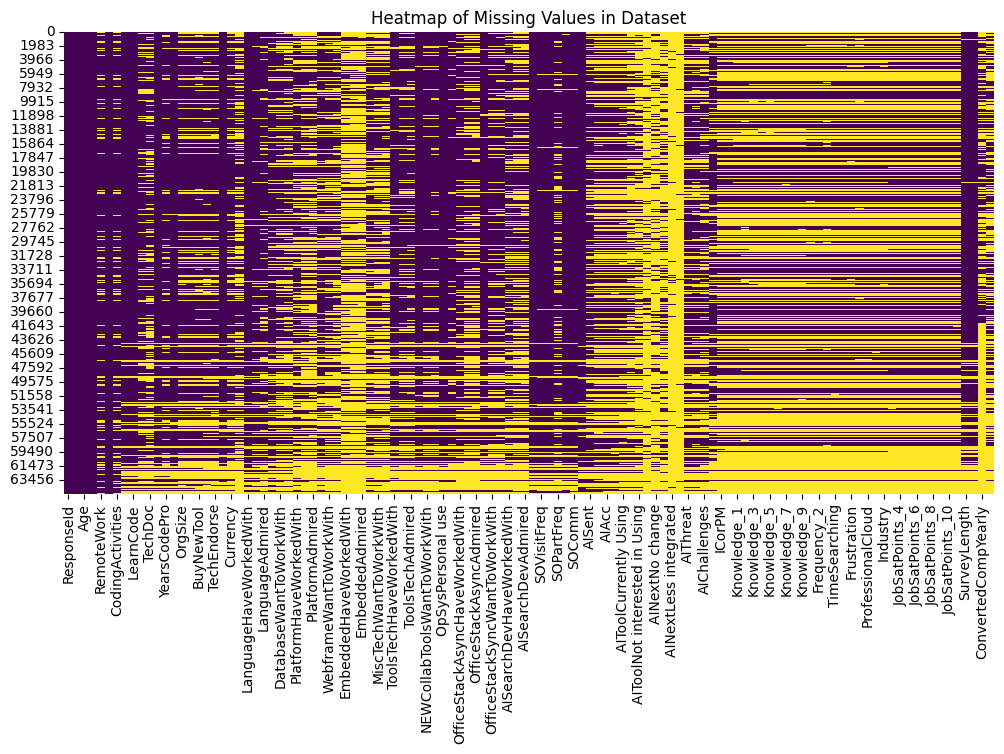

In [10]:
plt.figure(figsize=(12,6))

# Create heatmap of missing values
sns.heatmap(df.isnull(), 
            cbar=False, 
            cmap="viridis")

plt.title("Heatmap of Missing Values in Dataset")

##### Task 4: Count the number of missing rows for a specific column (e.g., `Employment`).


In [11]:
# Count missing values in Employment column
missing_employment = df["Employment"].isnull().sum()
print("Number of missing rows in Employment:", missing_employment)

Number of missing rows in Employment: 0


In [12]:
# Percentage of missing values in Employment
missing_percentage = (df["Employment"].isnull().sum() / len(df)) * 100
print("Percentage of missing Employment values:", missing_percentage)

Percentage of missing Employment values: 0.0


### 4. Imputing Missing Values
##### Task 5: Identify the most frequent (majority) value in a specific column (e.g., `Employment`).


In [13]:
# Find the most frequent (mode) value in Employment column
most_frequent_employment = df["Employment"].mode()[0]
print("Most frequent value in Employment:", most_frequent_employment)

Most frequent value in Employment: Employed, full-time


In [14]:
# Count how many times the most frequent value appears
frequency_count = df["Employment"].value_counts().iloc[0]
print("Frequency of most frequent Employment value:", frequency_count)

Frequency of most frequent Employment value: 39041


##### Task 6: Impute missing values in the `Employment` column with the most frequent value.



In [17]:
# Fill missing Employment values with the most frequent value
df["Employment"].fillna(most_frequent_employment, inplace=True)

# Verify after imputation
print("Missing values in Employment after imputation:", df["Employment"].isnull().sum())

Missing values in Employment after imputation: 0


/tmp/ipykernel_1237/4081647414.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Employment"].fillna(most_frequent_employment, inplace=True)


### 5. Visualizing Imputed Data
##### Task 7: Visualize the distribution of a column after imputation (e.g., `Employment`).


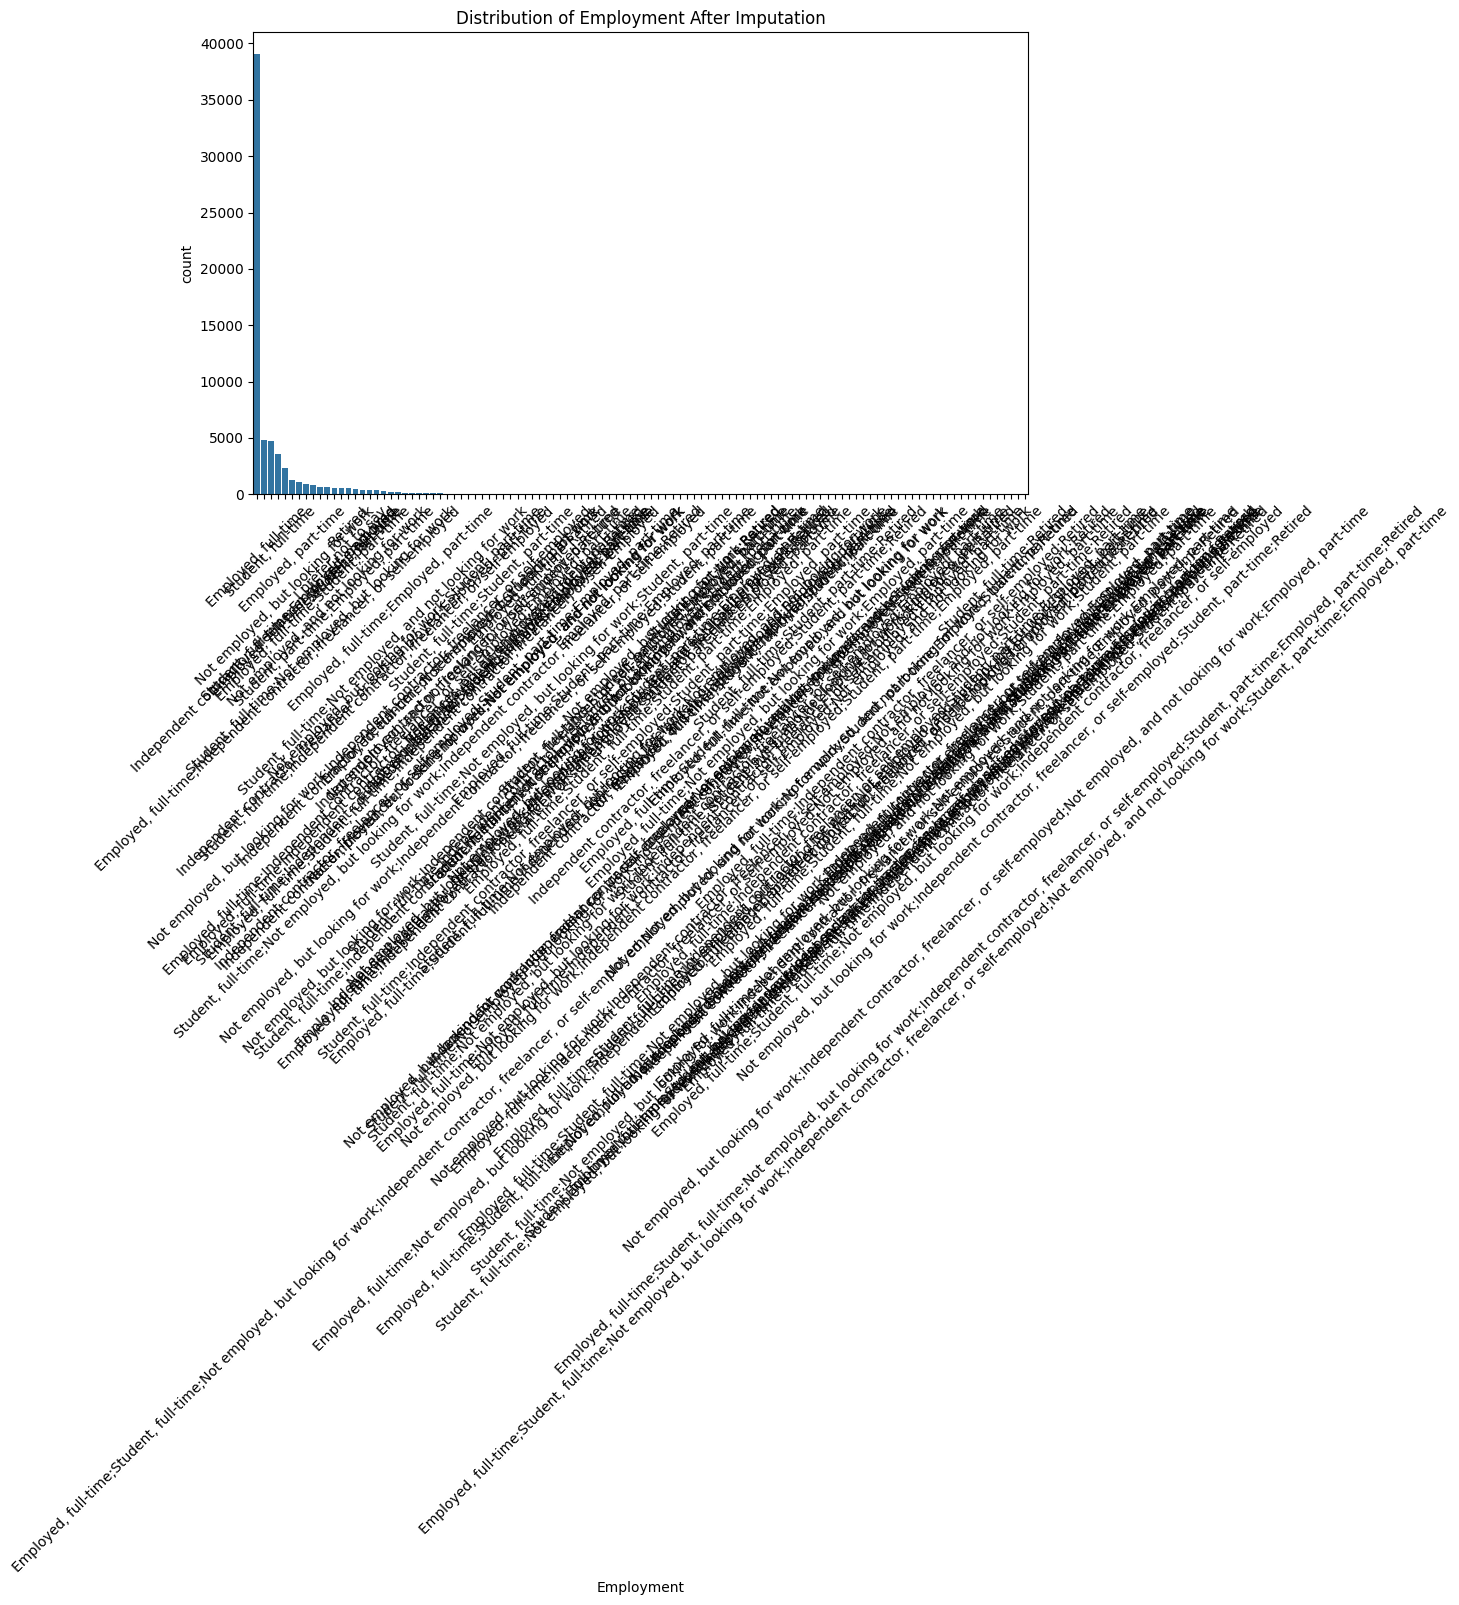

In [18]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="Employment", order=df["Employment"].value_counts().index)

plt.title("Distribution of Employment After Imputation")
plt.xticks(rotation=45)
plt.show()

### Summary


In this lab, you:
- Loaded the dataset into a pandas DataFrame.
- Identified missing values across all columns.
- Quantified missing values in specific columns.
- Imputed missing values in a categorical column using the most frequent value.
- Visualized the imputed data for better understanding.
  
